In [1]:
import numpy as np                           
import pandas as pd                                 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline           
from sklearn.compose import ColumnTransformer     
from sklearn.preprocessing import StandardScaler, RobustScaler      
from sklearn.preprocessing import OneHotEncoder       
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [2]:
data = pd.read_csv("..\\data\\train_post_modif_median.csv")

In [3]:
data.head()

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Model,Brand
0,2010,72000,CNG,Manual,First,26.60,58.16,1627.325,WAGON R LXI CNG,MARUTI
1,2015,41000,Diesel,Manual,First,19.67,126.20,11623.750,CRETA 1.6 CRDI SX OPTION,HYUNDAI
2,2011,46000,Petrol,Manual,First,18.20,88.70,4184.550,JAZZ V,HONDA
3,2012,87000,Diesel,Manual,First,20.77,88.76,5579.400,ERTIGA VDI,MARUTI
4,2013,40670,Diesel,Automatic,Second,15.20,140.80,16496.426,A4 NEW 2.0 TDI MULTITRONIC,AUDI


In [3]:
X = data.drop(columns=["Price"])
y = data["Price"] 

In [4]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(  # Split into train and test
    X, y,                                             # Features and target
    test_size=0.2,                                    # 20% test
    random_state=42                                   # Reproducibility
)

In [6]:
linreg_model1 = Pipeline(steps=[
    ("preprocess", preprocess),                        # Preprocess (fit on train only)
    ("model", LinearRegression())                      # Linear regression model
])

linreg_model1.fit(X_train, y_train)                     # Fit pipeline on training set only
print("Linear Regression trained.")

Linear Regression trained.


In [7]:
def evaluate_regression(model, X_test, y_test, name="model"):
    """
    Evaluate a regression model on the test set using:
    - MAE
    - RMSE
    - R²
    Also plots Actual vs Predicted.
    """
    preds = model.predict(X_test)                      # Predict on test features

    mae = mean_absolute_error(y_test, preds)           # Compute MAE
    rmse = np.sqrt(mean_squared_error(y_test, preds))  # Compute RMSE
    r2 = r2_score(y_test, preds)                       # Compute R² score

    print(f"\n--- {name} ---")                         # Print model name
    print(f"MAE : {mae:.4f}")                          # Print MAE
    print(f"RMSE: {rmse:.4f}")                         # Print RMSE
    print(f"R^2 : {r2:.4f}")                           # Print R²

    plt.figure()                                       # New figure
    plt.scatter(y_test, preds, s=8)                    # Scatter actual vs predicted
    plt.title(f"{name}: Actual vs Predicted")          # Title
    plt.xlabel("Actual")                               # X label
    plt.ylabel("Predicted")                            # Y label
    plt.show()                                         # Show plot

    return mae, rmse, r2                               # Return metrics


--- Linear Regression ---
MAE : 3201.1416
RMSE: 6275.3079
R^2 : 0.6299


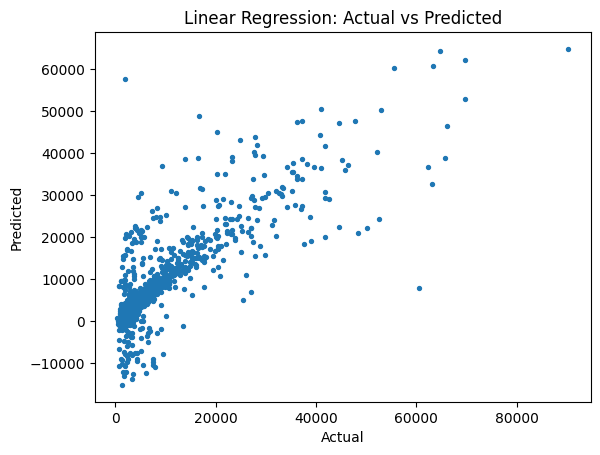

In [8]:
linreg_scores = evaluate_regression(                   # Evaluate baseline model
    linreg_model1,                                      # Pipeline
    X_test,                                            # Test features
    y_test,                                            # Test target
    "Linear Regression"                                # Name
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.5,                                    
    random_state=42                                   
)

In [10]:
linreg_model2 = Pipeline(steps=[
    ("preprocess", preprocess),                        
    ("model", LinearRegression())                     
])

linreg_model2.fit(X_train, y_train)                    
print("Linear Regression trained.")

Linear Regression trained.



--- Linear Regression ---
MAE : 2343.1471
RMSE: 4962.5283
R^2 : 0.7589


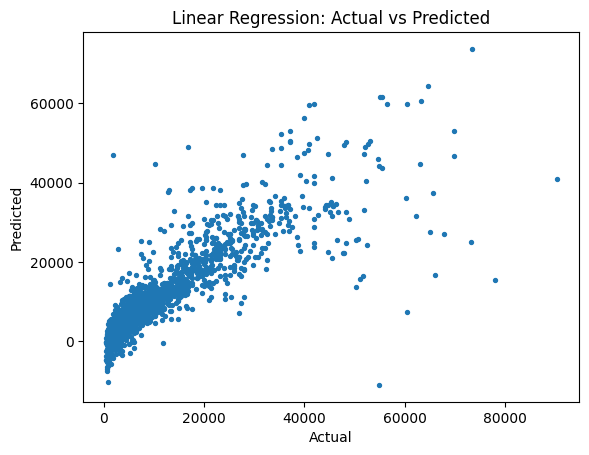

In [12]:
linreg_scores = evaluate_regression(                   # Evaluate baseline model
    linreg_model2,                                      # Pipeline
    X_test,                                            # Test features
    y_test,                                            # Test target
    "Linear Regression"                                # Name
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.8,                                    
    random_state=42                                   
)

In [14]:
linreg_model3 = Pipeline(steps=[
    ("preprocess", preprocess),                        
    ("model", LinearRegression())                     
])

linreg_model3.fit(X_train, y_train)                    
print("Linear Regression trained.")

Linear Regression trained.



--- Linear Regression ---
MAE : 3681.7255
RMSE: 7588.0705
R^2 : 0.4565


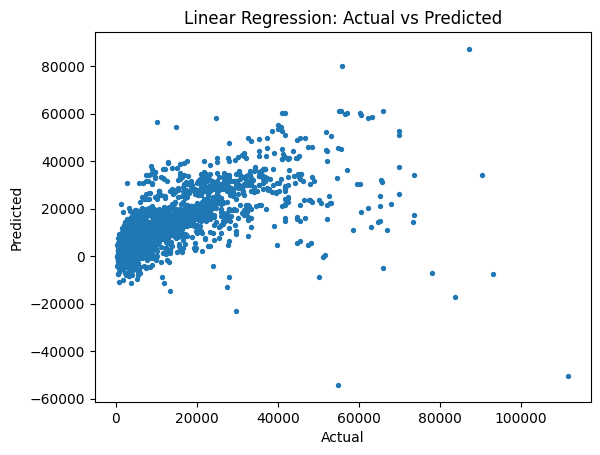

In [16]:
linreg_scores = evaluate_regression(                   # Evaluate baseline model
    linreg_model3,                                      # Pipeline
    X_test,                                            # Test features
    y_test,                                            # Test target
    "Linear Regression"                                # Name
)

In [17]:
data_drop = data.drop("Model", axis=1)
data_drop.head()

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Brand
0,2010,72000,CNG,Manual,First,26.60,58.16,1627.325,MARUTI
1,2015,41000,Diesel,Manual,First,19.67,126.20,11623.750,HYUNDAI
2,2011,46000,Petrol,Manual,First,18.20,88.70,4184.550,HONDA
3,2012,87000,Diesel,Manual,First,20.77,88.76,5579.400,MARUTI
4,2013,40670,Diesel,Automatic,Second,15.20,140.80,16496.426,AUDI


In [18]:
X = data_drop.drop(columns=["Price"])
y = data_drop["Price"] 

In [19]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.5,                                    
    random_state=42                                   
)

In [21]:
linreg_model4 = Pipeline(steps=[
    ("preprocess", preprocess),                       
    ("model", LinearRegression())                     
])

linreg_model4.fit(X_train, y_train)                     
print("Linear Regression trained.")

Linear Regression trained.



--- Linear Regression ---
MAE : 2879.7078
RMSE: 5345.5706
R^2 : 0.7202


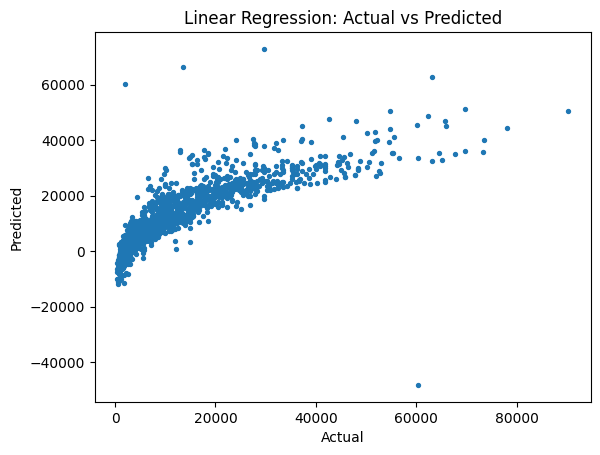

In [22]:
linreg_scores = evaluate_regression(                   # Evaluate baseline model
    linreg_model4,                                      # Pipeline
    X_test,                                            # Test features
    y_test,                                            # Test target
    "Linear Regression"                                # Name
)